# Netflix Movies Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mymoviedb.csv")

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9826 non-null   float64
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(3), object(6)
memory usage: 691.8+ KB


In [5]:
df.shape

(9837, 9)

# Data Cleaning

## Remove Unnecessary Columns

In [7]:
df = df.drop(['Overview', 'Poster_Url'],  axis=1)

In [8]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122.0,6.3,en,Thriller
3,2021-11-24,Encanto,2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War"


#### Reason: These columns are not useful for data analytics dashboarding.

## Convert Date Column

In [11]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9828 non-null   object        
 2   Popularity         9827 non-null   float64       
 3   Vote_Count         9826 non-null   float64       
 4   Vote_Average       9826 non-null   float64       
 5   Original_Language  9827 non-null   object        
 6   Genre              9826 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 538.1+ KB


## Extract Year

In [14]:
df['Year'] = df['Release_Date'].dt.year

In [16]:
df[['Release_Date', 'Year']].head()

,Release_Date,Year
0,2021-12-15,2021.0
1,2022-03-01,2022.0
2,2022-02-25,2022.0
3,2021-11-24,2021.0
4,2021-12-22,2021.0


## Split and Explode Genre Column

In [17]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')

In [18]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940.0,8.3,en,Action,2021.0
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940.0,8.3,en,Adventure,2021.0
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940.0,8.3,en,Science Fiction,2021.0
1,2022-03-01,The Batman,3827.658,1151.0,8.1,en,Crime,2022.0
1,2022-03-01,The Batman,3827.658,1151.0,8.1,en,Mystery,2022.0


## Remove Extra Spaces

In [19]:
df['Genre'] = df['Genre'].str.strip()

## Check Missing Values

In [22]:
df.isnull().sum()

Release_Date         10
Title                 9
Popularity           10
Vote_Count           11
Vote_Average         11
Original_Language    10
Genre                11
Year                 10
dtype: int64

In [23]:
df = df.dropna()

In [24]:
df.isnull().sum()

Release_Date         0
Title                0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Year                 0
dtype: int64

## Remove Duplicates

In [25]:
df.duplicated().sum()

np.int64(0)

#### Note: There is no dulicate value.

## Save Cleaned Dataset

In [26]:
df.to_csv("cleaned_movies.csv", index=False)

# Exploratory Data Analysis (EDA)

## Basic Statistical Summary

In [27]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average,Year
count,25792,25792.000000,25792.000000,25792.000000,25792.000000
mean,2006-07-17 17:34:02.307692544,42.000539,1504.881514,6.475725,2006.016051
min,1902-04-17 00:00:00,13.354000,0.000000,0.000000,1902.000000
25%,2000-09-01 00:00:00,16.365750,166.000000,6.000000,2000.000000
50%,2011-01-28 00:00:00,21.862000,490.000000,6.600000,2011.000000
75%,2017-08-30 00:00:00,36.503000,1501.000000,7.200000,2017.000000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000,2024.000000
std,NaN,113.343183,2743.047498,1.091310,15.491212


## Total Movies

In [51]:
df['Title'].nunique()

9512

## Genre Distribution

In [31]:
Genre_Counts = df['Genre'].value_counts()
Genre_Counts

Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: count, dtype: int64

### Insight:

Drama contributes nearly 39.4% of all Movies in the dataset.

## Top 10 Genres

In [33]:
df['Genre'].value_counts().head(10)

Genre
Drama        3744
Comedy       3031
Action       2686
Thriller     2488
Adventure    1853
Romance      1476
Horror       1470
Animation    1438
Family       1414
Fantasy      1308
Name: count, dtype: int64

### Insight:

Drama dominates in genres followed by comedy and action.

## Top 10 Highest Rated Movies

In [40]:
top_rated = df[['Title', 'Vote_Average', 'Vote_Count', 'Popularity']] \
.drop_duplicates(subset='Title') \
.sort_values(by='Vote_Average', ascending=False)

top_rated.head(10)

,Title,Vote_Average,Vote_Count,Popularity
9401,Kung Fu Master Huo Yuanjia,10.0,1.0,13.745
7349,Franco Escamilla: Por La Anécdota,9.2,92.0,16.158
2335,Impossible Things,9.1,82.0,36.466
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1,27.0,86.689
6738,Mission «Sky»,9.0,34.0,17.133
7411,My Sex Doll,9.0,4.0,16.088
7024,Sex School: Dorms of Desire,9.0,1.0,16.683
2401,The Three Deaths of Marisela Escobedo,9.0,183.0,35.767
7049,Bring the Soul: The Movie,8.9,323.0,16.652
8657,Burn the Stage: The Movie,8.9,332.0,14.471


#### Note: Movies with very low vote counts can sometimes receive perfect ratings, which may not represent overall audience opinion accurately. Therefore, we will filter out movies with low votes to improve the reliability of the analysis.

In [41]:
top_rated = df[df['Vote_Count'] > 300][
    ['Title', 'Vote_Average', 'Vote_Count', 'Popularity']
].drop_duplicates(subset='Title') \
.sort_values(by='Vote_Average', ascending=False)

top_rated.head(10)

,Title,Vote_Average,Vote_Count,Popularity
7049,Bring the Soul: The Movie,8.9,323.0,16.652
8657,Burn the Stage: The Movie,8.9,332.0,14.471
3156,Dilwale Dulhania Le Jayenge,8.7,3474.0,29.087
657,The Shawshank Redemption,8.7,20911.0,87.669
609,The Godfather,8.7,15614.0,93.136
1327,Schindler's List,8.6,12474.0,55.225
4196,Gabriel's Inferno Part III,8.6,946.0,23.690
1007,The Godfather: Part II,8.6,9393.0,65.324
1769,GoodFellas,8.5,9860.0,44.572
1069,Forrest Gump,8.5,22308.0,62.636


## Most Popular Movies

In [43]:
top_popular = df[['Title', 'Popularity', 'Vote_Average', 'Vote_Count']] \
.drop_duplicates(subset='Title') \
.sort_values(by='Popularity', ascending=False)

top_popular.head(10)

,Title,Popularity,Vote_Average,Vote_Count
0,Spider-Man: No Way Home,5083.954,8.3,8940.0
1,The Batman,3827.658,8.1,1151.0
2,No Exit,2618.087,6.3,122.0
3,Encanto,2402.201,7.7,5076.0
4,The King's Man,1895.511,7.0,1793.0
5,The Commando,1750.484,6.6,33.0
6,Scream,1675.161,6.8,821.0
7,Kimi,1601.782,6.3,206.0
8,Fistful of Vengeance,1594.013,5.3,114.0
9,Eternals,1537.406,7.2,4726.0


## Ratings vs Popularity

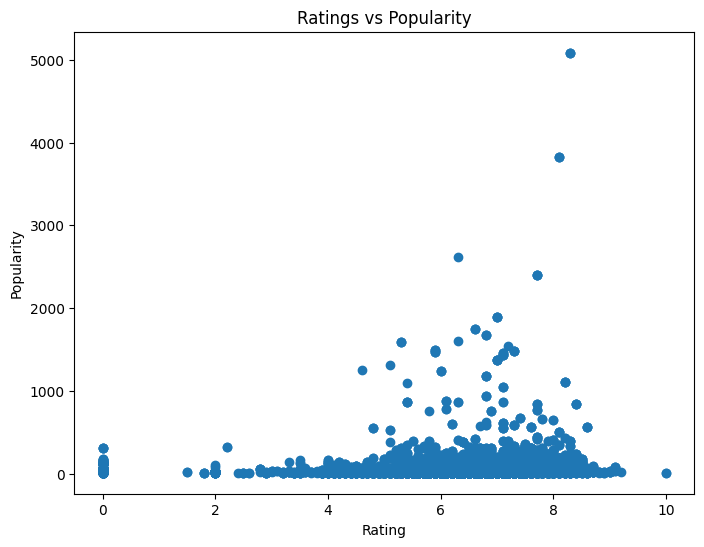

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df['Vote_Average'], df['Popularity'])

plt.xlabel("Rating")
plt.ylabel("Popularity")
plt.title("Ratings vs Popularity")

plt.show()

### Insight:
The analysis indicates that highly rated movies are not always the most popular, suggesting that audience popularity depends on factors beyond ratings alone.



## Movies Released Per Year

In [46]:
yearly_movies = df['Year'].value_counts().sort_index()

yearly_movies

Year
1902.0       3
1920.0       4
1921.0       5
1922.0       5
1925.0       2
          ... 
2020.0    1122
2021.0    1638
2022.0     471
2023.0      27
2024.0       4
Name: count, Length: 102, dtype: int64

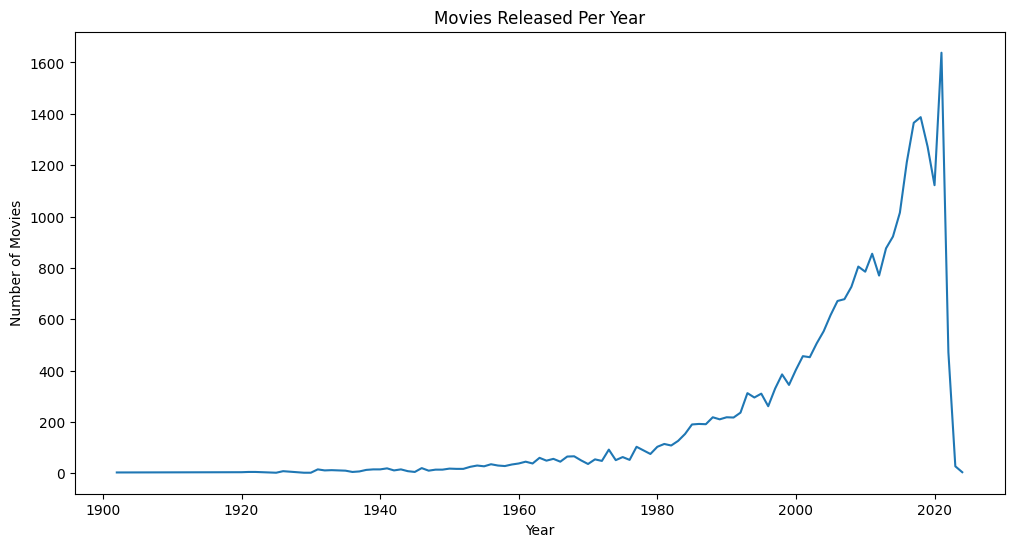

In [47]:
yearly_movies.plot(figsize=(12,6))

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

### Insight
 Movie production experienced significant growth after the year 2000, indicating a major expansion in the global film industry and increased content creation over time.

## Most Common Languages

In [48]:
df['Original_Language'].value_counts().head(10)

Original_Language
en    20018
ja     2025
fr      692
es      659
ko      420
zh      364
cn      299
it      251
ru      229
de      198
Name: count, dtype: int64

### Insight:
* English dominates movie production in the dataset.

## Correlation Analysis

In [50]:
df[['Popularity', 'Vote_Average', 'Vote_Count']].corr()

,Popularity,Vote_Average,Vote_Count
Popularity,1.000000,0.068280,0.146363
Vote_Average,0.068280,1.000000,0.248322
Vote_Count,0.146363,0.248322,1.000000


### Correlation Summary
The analysis reveals weak correlations among popularity, ratings, and vote counts, suggesting that audience behavior and movie success cannot be explained by a single factor alone.

## Final Insights

- Drama is the most dominant genre in the dataset, accounting for nearly 39.4% of all movies, followed by Comedy and Action.

- The number of movies released per year increased significantly after 2000, reflecting major growth in global film production over time.

- The analysis indicates that highly rated movies are not always the most popular, suggesting that audience popularity depends on factors beyond ratings alone.

- Correlation analysis revealed weak relationships among popularity, ratings, and vote counts, indicating that movie success is influenced by multiple independent factors.

- English-language movies dominate the dataset, while other languages contribute smaller shares to overall movie production.

- Movies with higher vote counts generally tend to receive slightly better ratings, suggesting that audience engagement may influence rating reliability.

- A noticeable decline in movie releases was observed during the COVID-19 period (2019–2020), indicating temporary disruption in film production activity.